# Analysis Online Inference Finite

In [9]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

HERE = Path(os.getcwd())
PATH_DATA = HERE.parent / '01_aggregated_datasets' / 'inference_online_finite_llama3_70b'

In [10]:
from utilities import plot_setup, plot_options_default, save_figure, set_min_ticks

In [11]:
# plotting options
_ = plot_setup(plot_options_default)

## Read Data

In [12]:
# path for data
path_results = PATH_DATA / 'metadata.csv'

# save path
output_directory = HERE / "plots" 
save_flag = 1

In [13]:
df_results = pd.read_csv(path_results)
df_results

,_repeat,burstiness_x,dataset-name,dataset-path,end_time_exc,hf-output-len,id,num-prompts,request_rate_x,seed,...,p90_e2el_ms,start_time_vllm,end_time_vllm,start_time,end_time,run_completed,execution_time_seconds,path_run,peak_power[W],mean_power[W]
0,0,100000,hf,likaixin/InstructCoder,2025-11-30 15:41:52.015074,256,1,1000,10,0,...,5114.628401,2025-11-30 15:41:38,2025-11-30 15:43:22.123269388,2025-11-30 15:39:40.303018,2025-11-30 15:41:52.015074,True,118.9,/projects/aiuserapps/genai_power_dataset/01_ag...,2351.683114,2085.306406
1,0,100000,hf,likaixin/InstructCoder,2025-11-30 15:43:18.318080,256,2,1000,20,0,...,5457.068536,2025-11-30 15:43:18,2025-11-30 15:44:12.522184050,2025-11-30 15:42:12.017302,2025-11-30 15:43:18.318080,True,56.0,/projects/aiuserapps/genai_power_dataset/01_ag...,2348.551505,2265.948935
2,0,100000,hf,likaixin/InstructCoder,2025-11-30 15:44:27.872271,256,3,1000,30,0,...,5892.459001,2025-11-30 15:44:27,2025-11-30 15:45:05.159787518,2025-11-30 15:43:38.320088,2025-11-30 15:44:27.872271,True,39.6,/projects/aiuserapps/genai_power_dataset/01_ag...,2601.319313,2446.739765
3,0,100000,hf,likaixin/InstructCoder,2025-11-30 15:45:29.534129,256,4,1000,40,0,...,6729.245408,2025-11-30 15:45:29,2025-11-30 15:45:59.162391635,2025-11-30 15:44:47.874236,2025-11-30 15:45:29.534129,True,31.6,/projects/aiuserapps/genai_power_dataset/01_ag...,2769.148345,2540.255585
4,0,100000,hf,likaixin/InstructCoder,2025-11-30 15:46:26.631815,256,5,1000,50,0,...,7832.867683,2025-11-30 15:46:26,2025-11-30 15:46:51.619327869,2025-11-30 15:45:49.536079,2025-11-30 15:46:26.631815,True,27.1,/projects/aiuserapps/genai_power_dataset/01_ag...,2829.527007,2595.686989
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1021,2,100000,hf,mgoin/mlperf-inference-llama2-data,2025-12-01 11:24:30.835061,1024,1022,1000,600,2,...,26432.294859,2025-12-01 11:24:30,2025-12-01 11:25:08.579574077,2025-12-01 11:23:38.025362,2025-12-01 11:24:30.835061,True,43.3,/projects/aiuserapps/genai_power_dataset/01_ag...,2800.294105,2440.678043
1022,2,100000,hf,mgoin/mlperf-inference-llama2-data,2025-12-01 11:25:43.726295,1024,1023,1000,700,2,...,26966.979649,2025-12-01 11:25:43,2025-12-01 11:26:21.993341316,2025-12-01 11:24:50.850208,2025-12-01 11:25:43.726295,True,43.7,/projects/aiuserapps/genai_power_dataset/01_ag...,2775.848576,2409.438468
1023,2,100000,hf,mgoin/mlperf-inference-llama2-data,2025-12-01 11:26:56.188304,1024,1024,1000,800,2,...,26557.868666,2025-12-01 11:26:55,2025-12-01 11:27:33.519299700,2025-12-01 11:26:03.741722,2025-12-01 11:26:56.188304,True,43.3,/projects/aiuserapps/genai_power_dataset/01_ag...,2781.419271,2427.470511
1024,2,100000,hf,mgoin/mlperf-inference-llama2-data,2025-12-01 11:28:09.552506,1024,1025,1000,900,2,...,27335.065631,2025-12-01 11:28:09,2025-12-01 11:28:48.405966463,2025-12-01 11:27:16.203424,2025-12-01 11:28:09.552506,True,44.1,/projects/aiuserapps/genai_power_dataset/01_ag...,2771.807309,2391.715122


In [14]:
# ignore failed runs
print(f"Number of runs: {df_results.shape[0]}")
ifailed = (df_results["run_completed"] == False)
print(f"Failed runs: {ifailed.sum()}")
df_results = df_results.loc[~ifailed].copy()

Number of runs: 1026
Failed runs: 2


In [15]:
# rename some columns
if "request_rate_x" in df_results.columns:
    df_results["request_rate"] = df_results["request_rate_x"]
if "completed" in df_results.columns:
    df_results["completed_percentage"] = df_results["completed"] / df_results["num_prompts"]
    
if "hf-output-len" in df_results.columns:
    df_results.loc[df_results["hf-output-len"].isna(), "hf-output-len"] = 0
else:
    df_results["hf-output-len"] = 0

In [16]:
print(df_results.columns)

Index(['_repeat', 'burstiness_x', 'dataset-name', 'dataset-path',
       'end_time_exc', 'hf-output-len', 'id', 'num-prompts', 'request_rate_x',
       'seed', 'start_time_exc', 'date', 'endpoint_type', 'backend', 'label',
       'model_id', 'tokenizer_id', 'num_prompts', 'request_rate_y',
       'burstiness_y', 'max_concurrency', 'duration', 'completed',
       'total_input_tokens', 'total_output_tokens', 'request_throughput',
       'request_goodput', 'output_throughput', 'total_token_throughput',
       'max_output_tokens_per_s', 'max_concurrent_requests', 'mean_ttft_ms',
       'median_ttft_ms', 'std_ttft_ms', 'p10_ttft_ms', 'p30_ttft_ms',
       'p50_ttft_ms', 'p70_ttft_ms', 'p90_ttft_ms', 'mean_tpot_ms',
       'median_tpot_ms', 'std_tpot_ms', 'p10_tpot_ms', 'p30_tpot_ms',
       'p50_tpot_ms', 'p70_tpot_ms', 'p90_tpot_ms', 'mean_itl_ms',
       'median_itl_ms', 'std_itl_ms', 'p10_itl_ms', 'p30_itl_ms', 'p50_itl_ms',
       'p70_itl_ms', 'p90_itl_ms', 'mean_e2el_ms', 'median_e2el

In [17]:
# normalize metrics
df_results["output_throughput_sec"] = df_results["output_throughput"] /df_results["request_rate"]
df_results["request_throughput_rate"] = df_results["request_throughput"] / df_results["request_rate"]
df_results["mean_time_per_request"] = 1 / df_results["request_throughput"]

In [18]:
# get other metrics
run_ids = df_results.to_dict(orient="records")
res = []

for row in run_ids:
# row = run_ids[0]

    filepath = Path(row["path_run"])
    df = pd.read_parquet(filepath)

    # save information to plot
    d = {
        "time": df.index[-1],
        "power_avg": df["power[W]"].mean(numeric_only=True)*1e-3,
        "power_std": df["power[W]"].std(numeric_only=True)*1e-3,
        "energy": ((df["power[W]"]*1e-3)/(10*60*60)).sum(),
        # "request_rate": row["request_rate_x"],
        "model": row["dataset-path"],
        "output_token_length":row["hf-output-len"],
        # "seed":row["seed"],
        "repeat":row["_repeat"]
    }
    
    res.append(
        {
            **row,
            **d
        }
    )
    
df_results = pd.DataFrame(res)


# Aggregated Plots

In [19]:
map_dataset = {
    'likaixin/InstructCoder':"Coding Dataset",
    'mgoin/mlperf-inference-llama2-data':"Conversation Dataset"
}

In [20]:
def plot_performance_metrics(
    df_results, 
    values, 
    index="request_rate", 
    columns=["hf-output-len", "dataset-path"],
    aggfunc="median"
    ):
    """
    Plot performance metrics with min/max shaded areas.
    
    Parameters:
    -----------
    df_results : DataFrame
        Results dataframe with performance metrics
    values : dict
        Dictionary of metrics to plot with format:
        {metric_name: {"label": "Display Label", "scale": scale_factor}}
    index : str
        Column to use as x-axis (default: "request_rate")
    columns : list
        Columns to pivot on (default: ["hf-output-len", "dataset-path"])
    aggfunc : str
        Aggregation function for central tendency (default: "median")
    
    Returns:
    --------
    fig, axes : matplotlib figure and axes objects
    """
    
    # Compute statistics
    df_plot_mean = df_results.pivot_table(
        index=index,
        columns=columns,
        values=values.keys(), 
        aggfunc=aggfunc
    )
    
    df_plot_low = df_results.pivot_table(
        index=index,
        columns=columns,
        values=values.keys(), 
        # aggfunc="min",
        aggfunc=lambda x: np.nanpercentile(x, 10)
    )
    
    df_plot_high = df_results.pivot_table(
        index=index,
        columns=columns,
        values=values.keys(), 
        # aggfunc="max",
        aggfunc=lambda x: np.nanpercentile(x, 90)
    )
    
    # Get unique dataset paths
    dataset_paths = df_results[columns[-1]].unique()
    n_datasets = len(dataset_paths)
    
    # Create figure
    fig, axes = plt.subplots(len(values), n_datasets, 
                             figsize=(8*n_datasets, 5*len(values)), 
                             sharex=True, sharey="row")
    
    # Ensure axes is 2D
    if (n_datasets == 1):
        axes = np.asarray([axes])
    if (len(values) == 1):
        axes = np.asarray([axes])
    
    # Store handles and labels for legend
    handles, labels = None, None
    
    for col_idx, dataset in enumerate(dataset_paths):
        for row_idx, (value, d) in enumerate(values.items()):
            ax = axes[row_idx, col_idx]
            
            # Filter data for this dataset
            data_mean = (df_plot_mean[value] * d["scale"]).xs(dataset, level=columns[-1], axis=1)
            data_min = (df_plot_low[value] * d["scale"]).xs(dataset, level=columns[-1], axis=1)
            data_max = (df_plot_high[value] * d["scale"]).xs(dataset, level=columns[-1], axis=1)
            
            # Plot mean lines and get colors
            lines = data_mean.plot(marker=".", ax=ax, legend=False)
            
            # Get handles and labels from first plot
            if handles is None and labels is None:
                handles, labels = ax.get_legend_handles_labels()
            
            # Add shaded areas for each series
            for col in data_mean.columns:
                # Get the color of the corresponding line
                line_color = lines.get_lines()[list(data_mean.columns).index(col)].get_color()
                
                # Fill between min and max
                ax.fill_between(
                    data_mean.index,
                    data_min[col],
                    data_max[col],
                    color=line_color,
                    alpha=0.2,
                    linewidth=0
                )
            
            ax.set_xlabel("Requests Rate (Prompts/second)")
            ax.set_ylabel(d["label"])
            ax.set_xscale("log")
            
            if row_idx == 0:
                ax.set_title(map_dataset[dataset])
            ax.grid(alpha=0.3)
    
    # Add a single legend below the figure
    fig.legend(
        handles, 
        labels, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1), 
        ncol=len(labels), 
        title="Output Token Length"
    )
    
    plt.tight_layout()
    
    return fig, axes

## Input/Output

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-20_online_inference_finite_aggregated_basic.png


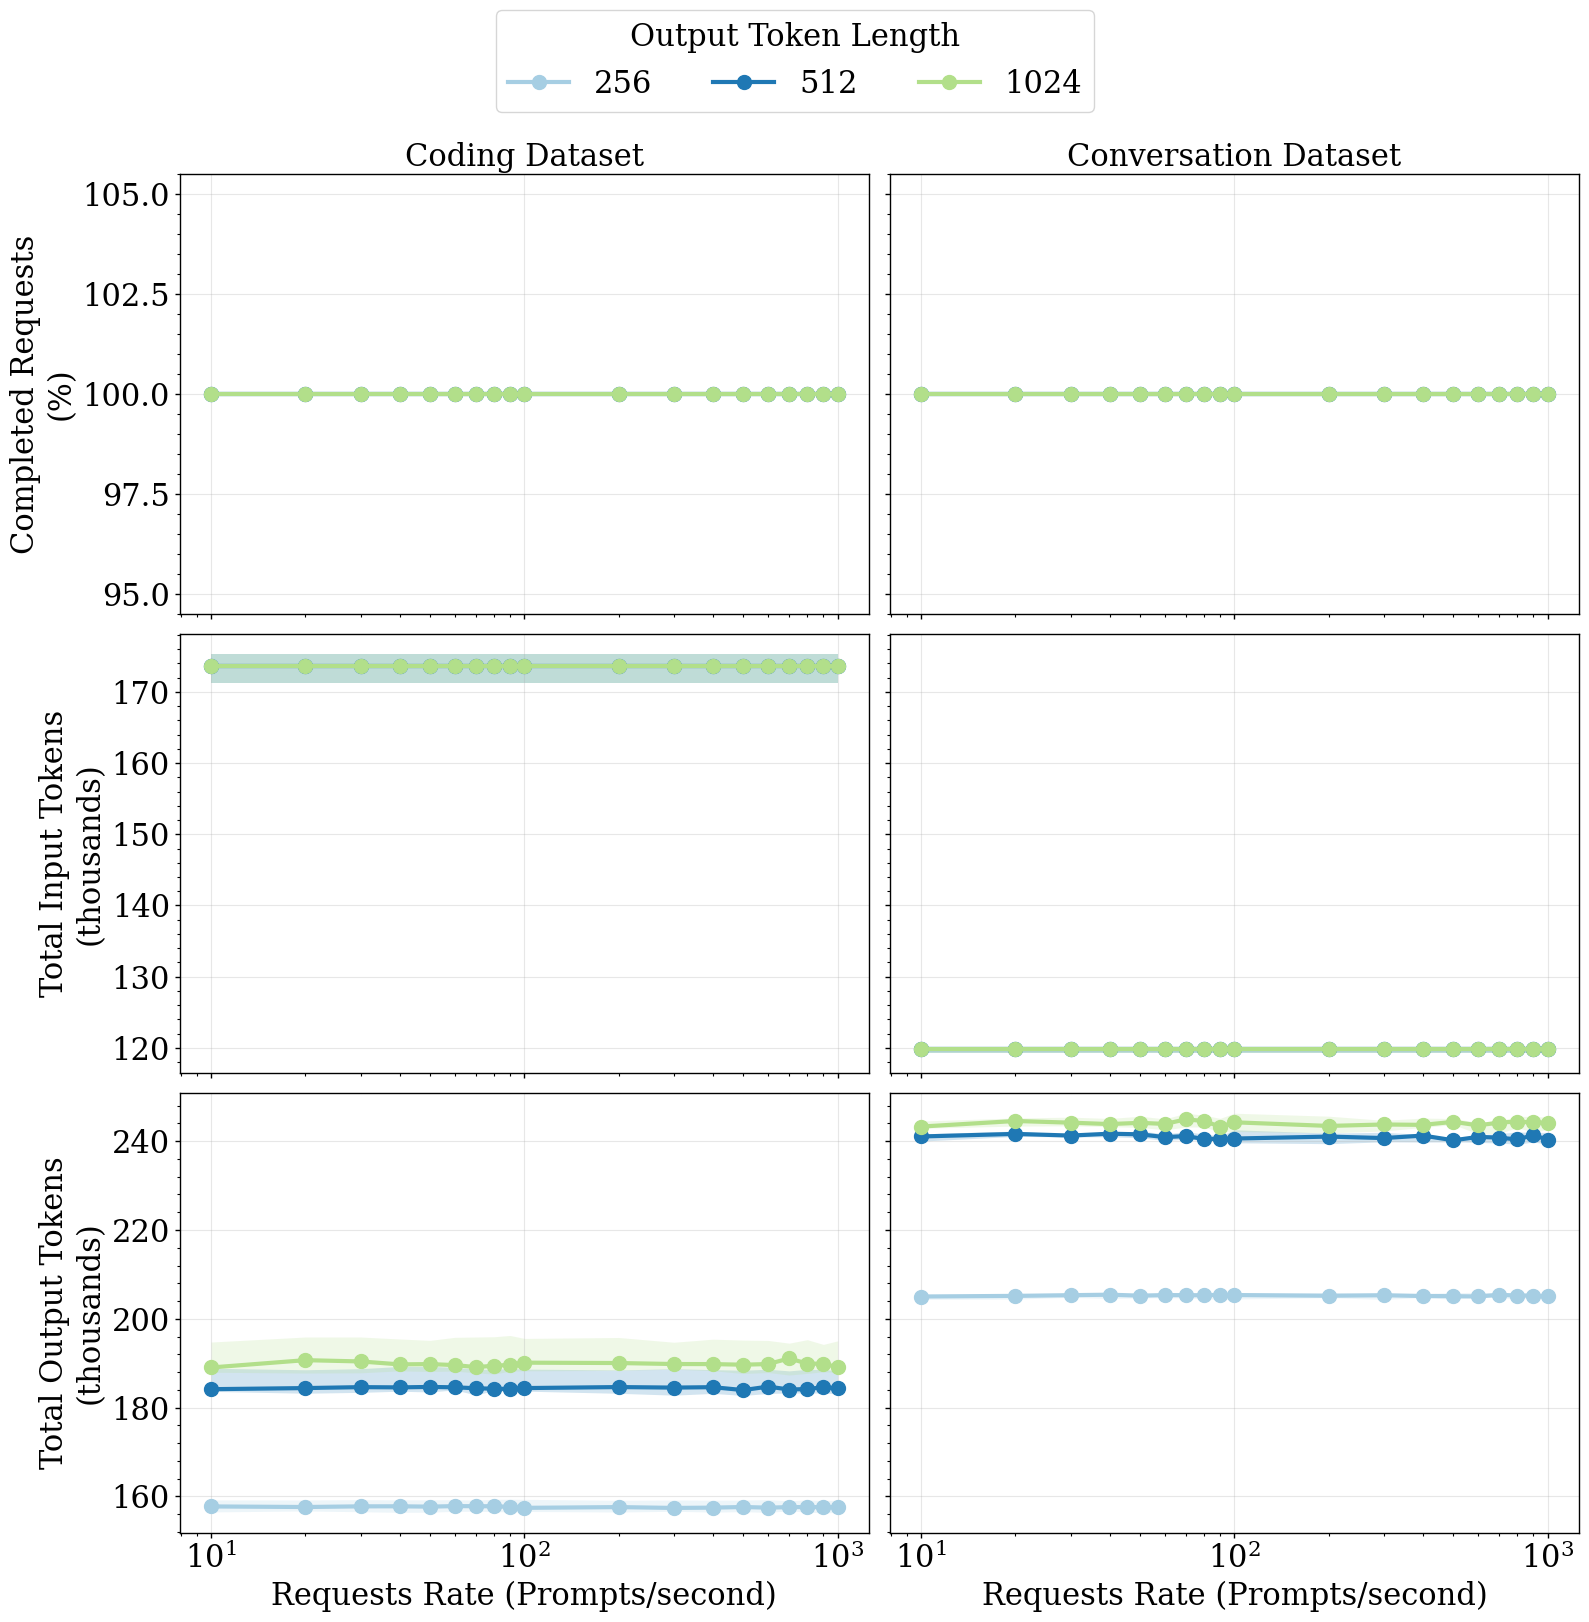

In [21]:
# Example usage:
values = {
    'completed_percentage': {"label": "Completed Requests\n(%)", "scale": 100},
    'total_input_tokens': {"label": "Total Input Tokens\n(thousands)", "scale": 1e-3},
    'total_output_tokens': {"label": "Total Output Tokens\n(thousands)", "scale": 1e-3},
    # "execution_time_seconds": {"label": "Execution Time\n(seconds)", "scale": 1},
}

fig, axes = plot_performance_metrics(
    df_results=df_results,
    values=values,
    index="request_rate",
    columns=["hf-output-len", "dataset-path"],
    aggfunc="median"
)

for ax in axes.flatten():
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)

save_figure(
    fig=fig,
    plot_name="online_inference_finite_aggregated_basic",
    file_format=["png"],  # ["svg", "png", "pdf"],
    full_path=output_directory,
    save_flag=save_flag
)

## Throughput/Latency

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-20_online_inference_finite_aggregated_performance.png


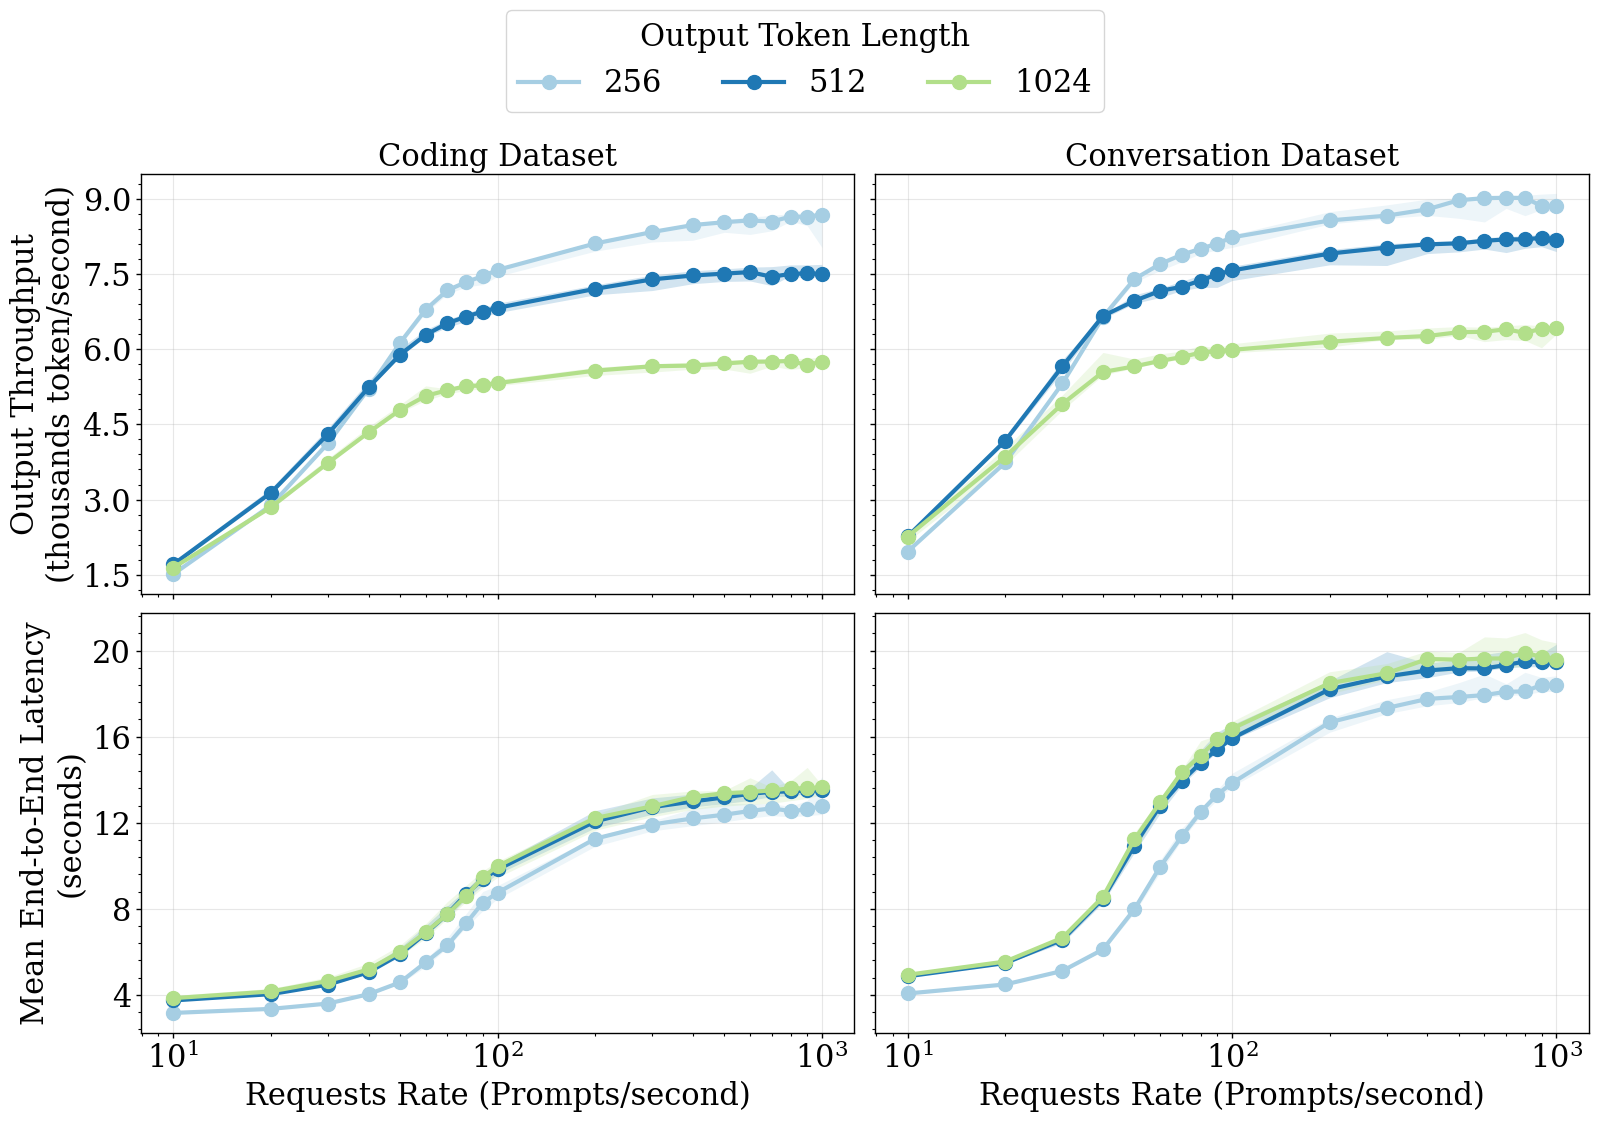

In [22]:
values = {
    'output_throughput': {"label": "Output Throughput\n(thousands token/second)", "scale": 1e-3},
    'mean_e2el_ms': {"label": "Mean End-to-End Latency\n(seconds)", "scale": 1e-3}
}

fig, axes = plot_performance_metrics(
    df_results=df_results,
    values=values,
    index="request_rate",
    columns=["hf-output-len", "dataset-path"],
    aggfunc="median"
)


for ax in axes.flatten():
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)
    
    
save_figure(
    fig=fig,
    plot_name="online_inference_finite_aggregated_performance",
    file_format=["png"],  # ["svg", "png", "pdf"],
    full_path=output_directory,
    save_flag=save_flag
)

## Power

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-20_online_inference_finite_aggregated_power.png


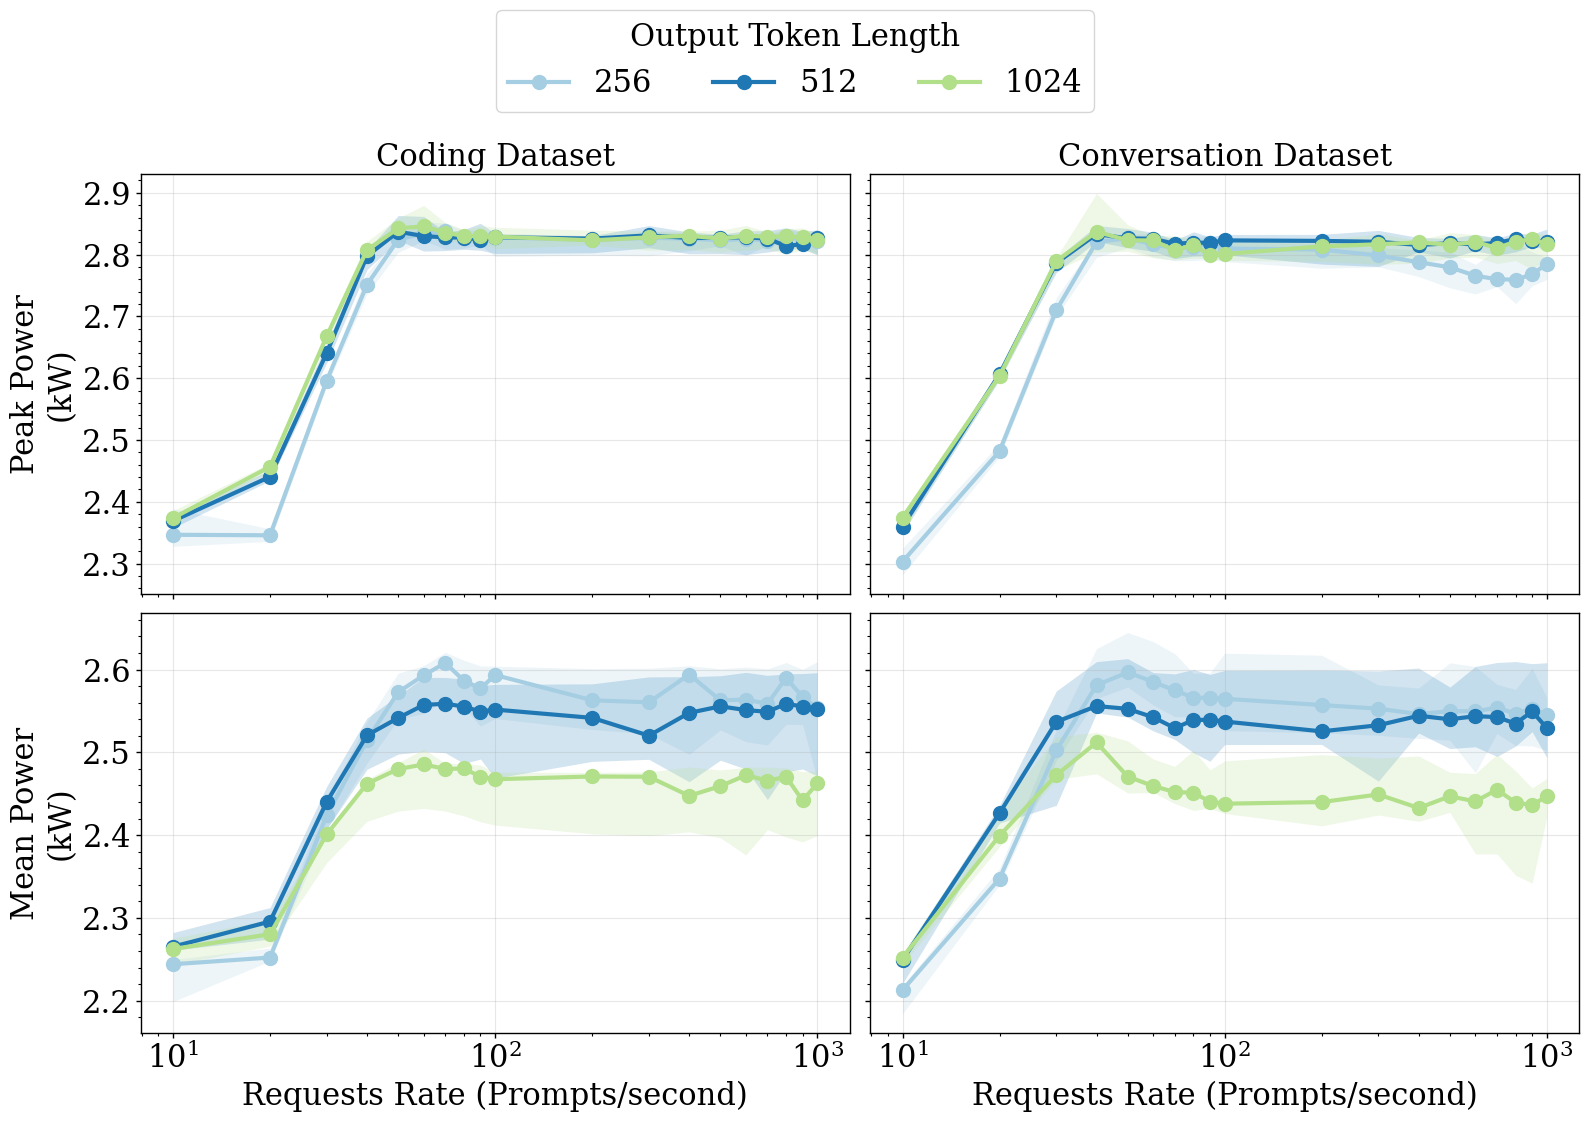

In [23]:
# Example usage:
values = {
    'peak_power[W]': {"label": "Peak Power\n(kW)", "scale": 1e-3},
    'mean_power[W]': {"label": "Mean Power\n(kW)", "scale": 1e-3},
}

fig, axes = plot_performance_metrics(
    df_results=df_results,
    values=values,
    index="request_rate",
    columns=["hf-output-len", "dataset-path"],
    aggfunc="median"
)

for ax in axes.flatten():
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)

save_figure(
    fig=fig,
    plot_name="online_inference_finite_aggregated_power",
    file_format=["png"],  # ["svg", "png", "pdf"],
    full_path=output_directory,
    save_flag=save_flag
)

## Aggregated Across Datasets

In [24]:
def plot_performance_metrics_mixed(
    fig, ax,
    df_results, 
    value, 
    index="request_rate", 
    aggfunc="median"
    ):
    
    # pivot column
    columns = ["hf-output-len"]
    
    # Compute statistics
    df_plot_mean = df_results.pivot_table(
        index=index,
        columns=columns,
        values=value["value"], 
        aggfunc=aggfunc
    )
    
    df_plot_low = df_results.pivot_table(
        index=index,
        columns=columns,
        values=value["value"], 
        # aggfunc="min",
        aggfunc=lambda x: np.nanpercentile(x, 10)
    )
    
    df_plot_high = df_results.pivot_table(
        index=index,
        columns=columns,
        values=value["value"], 
        # aggfunc="max",
        aggfunc=lambda x: np.nanpercentile(x, 90)
    )
    
    # Store handles and labels for legend
    handles, labels = None, None
            
    # Filter data for this dataset
    data_mean = (df_plot_mean * value["scale"])
    data_min = (df_plot_low * value["scale"])
    data_max = (df_plot_high * value["scale"])
    
    # Plot mean lines and get colors
    lines = data_mean.plot(marker=".", ax=ax, legend=False)
    
    # Get handles and labels from first plot
    if handles is None and labels is None:
        handles, labels = ax.get_legend_handles_labels()
    
    # Add shaded areas for each series
    for col in data_mean.columns:
        # Get the color of the corresponding line
        line_color = lines.get_lines()[list(data_mean.columns).index(col)].get_color()
        
        # Fill between min and max
        ax.fill_between(
            data_mean.index,
            data_min[col],
            data_max[col],
            color=line_color,
            alpha=0.2,
            linewidth=0
        )
    
    ax.set_xlabel("Requests Rate (Prompts/second)")
    ax.set_ylabel(value["label"])
    
    plt.tight_layout()
    
    return fig, ax, handles, labels

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-20_online_inference_finite_aggregated_datasets.png


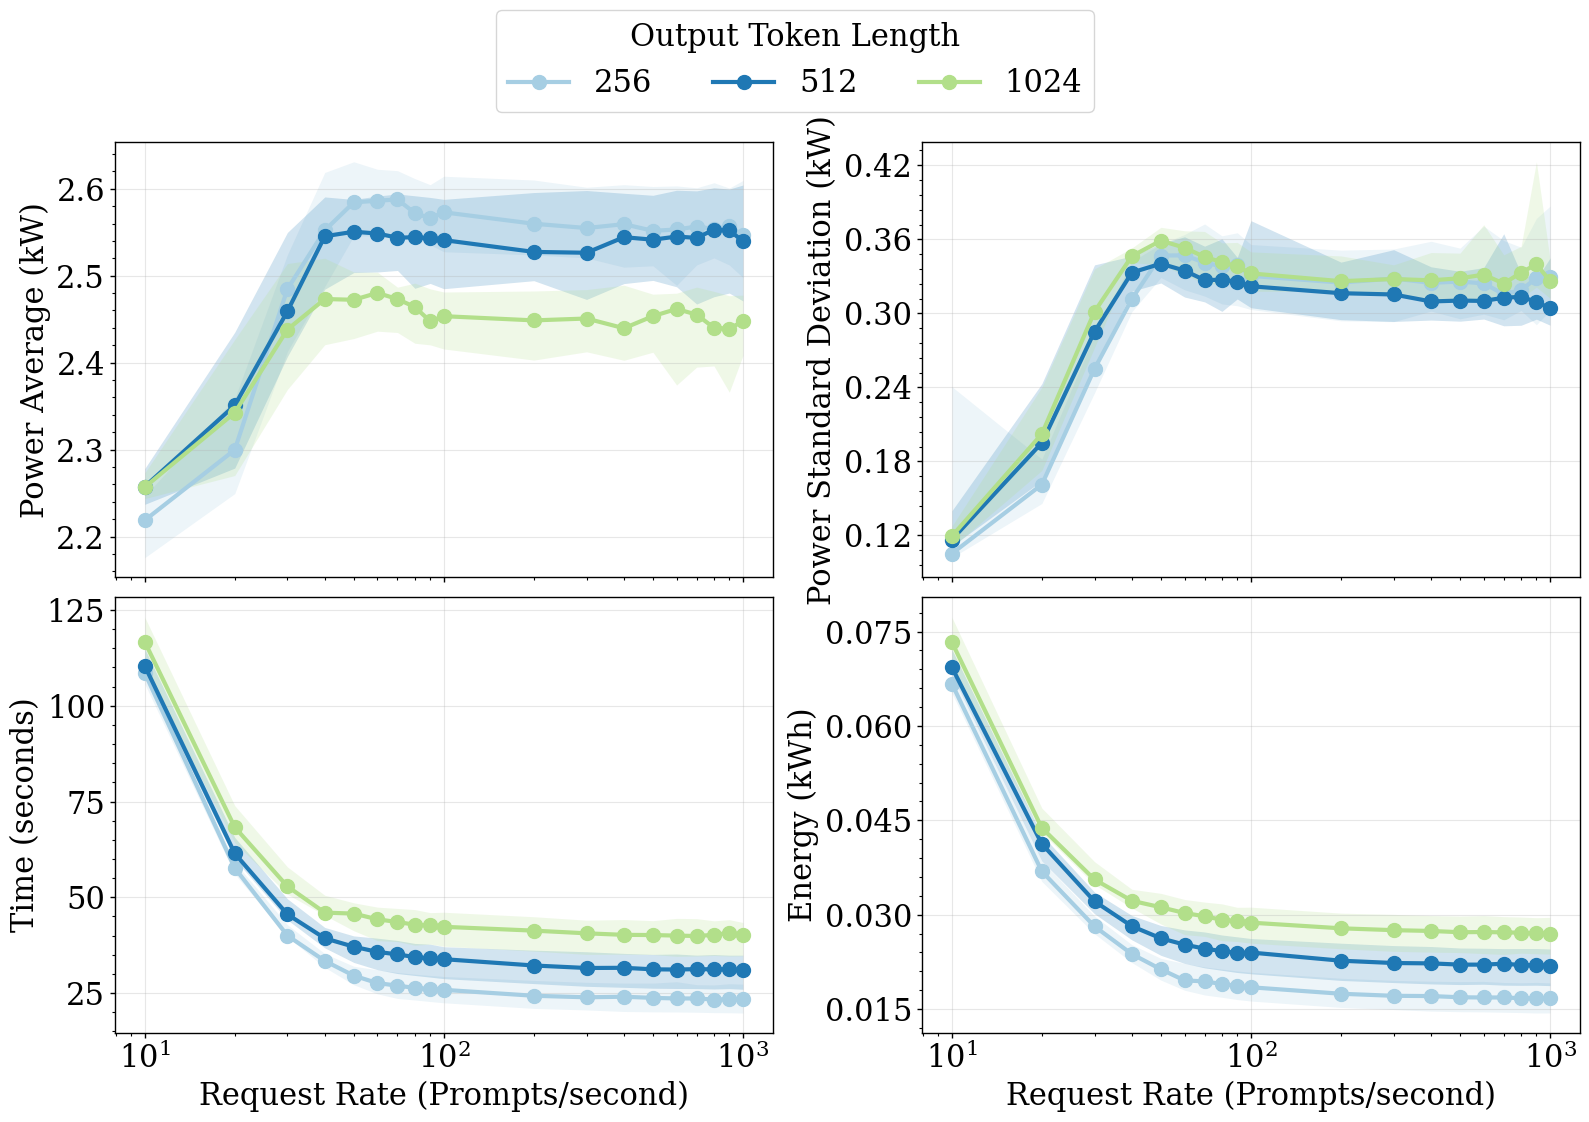

In [25]:
# Create the figure
fig, axes = plt.subplots(2,2, figsize=(16, 10), sharex=True)
ax1, ax2, ax3, ax4 = axes.flatten()

# ---------------------
values = {
    "value":"time", 
    "label": "Time (seconds)",
    "scale": 1
}

# ---------------------
values = {
    "value":"power_avg", 
    "label": "Power Average (kW)",
    "scale": 1
}
fig, ax1, handles, labels = plot_performance_metrics_mixed(
    fig, ax1,
    df_results=df_results,
    value=values,
    index="request_rate",
    aggfunc="median"
)

# ---------------------
values = {
    "value":"power_std", 
    "label": 'Power Standard Deviation (kW)',
    "scale": 1
}
fig, ax2, handles, labels = plot_performance_metrics_mixed(
    fig, ax2,
    df_results=df_results,
    value=values,
    index="request_rate",
    aggfunc="median"
)

# ---------------------
values = {
    "value":"time", 
    "label": "Time (seconds)",
    "scale": 1
}
fig, ax3, handles, labels = plot_performance_metrics_mixed(
    fig, ax3,
    df_results=df_results,
    value=values,
    index="request_rate",
    aggfunc="median"
)

# ---------------------
values = {
    "value":"energy", 
    "label": 'Energy (kWh)',
    "scale": 1
}
fig, ax4, handles, labels = plot_performance_metrics_mixed(
    fig, ax4,
    df_results=df_results,
    value=values,
    index="request_rate",
    aggfunc="median"
)


# Add a single legend below the figure
fig.legend(
    handles, 
    labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 1), 
    ncol=len(labels), 
    title="Output Token Length"
)

for ax in axes.flatten():
    ax.set_xlabel('Request Rate (Prompts/second)')
    ax.grid(False, which='minor')
    ax.grid(which='major', alpha=0.3)
    
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)
    ax.set_xscale("log")
    
# Adjust layout
plt.tight_layout()
# plt.show()

save_figure(
    fig=fig,
    plot_name="online_inference_finite_aggregated_datasets",
    file_format=["png"],  # ["svg", "png", "pdf"],
    full_path=output_directory,
    save_flag=save_flag
)

# Plot Power Profiles

Saved: /kfs2/projects/aiuserapps/genai_power_dataset/02_analysis_scripts/plots/2026-03-20_online_inference_finite_power.png


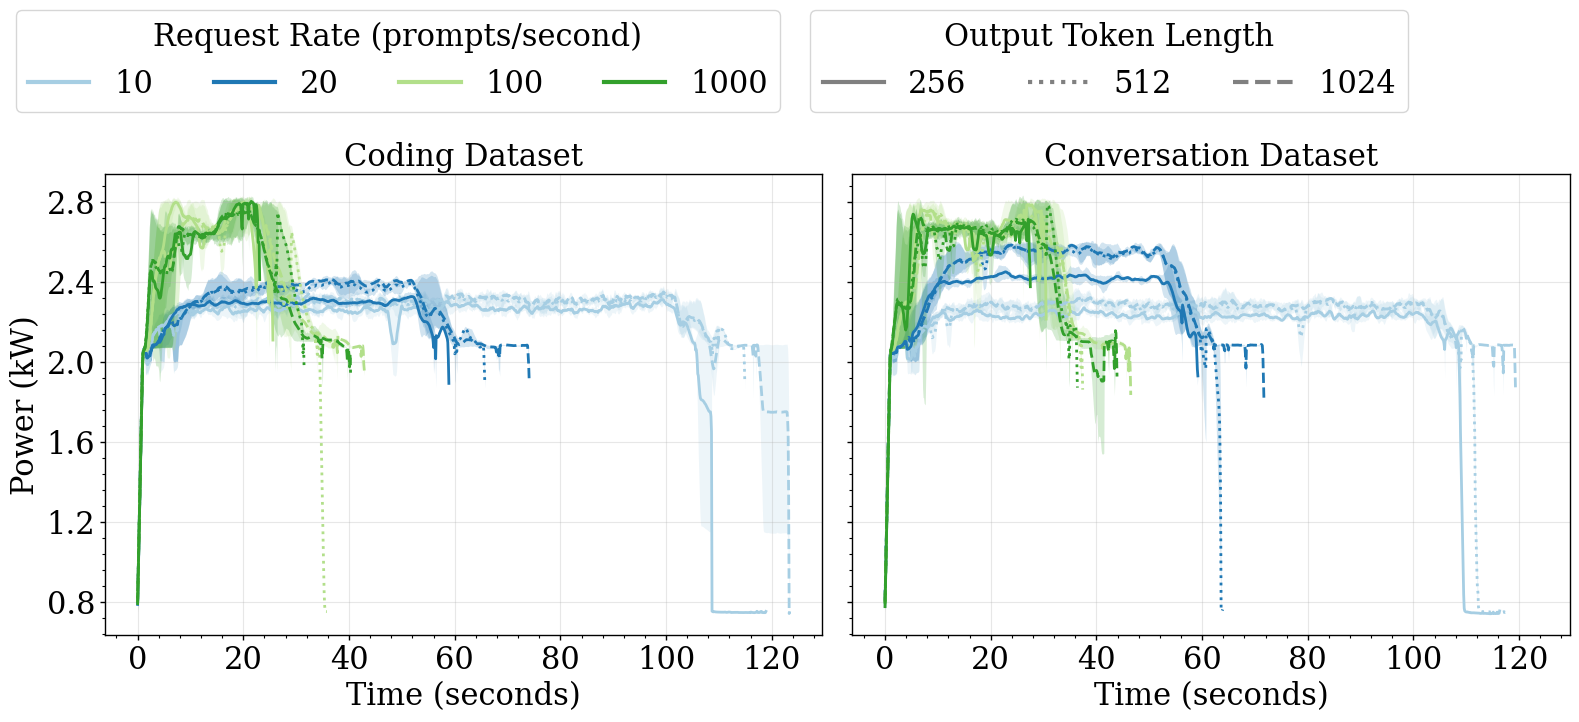

In [26]:
# Configuration
color_col = "request_rate"
linestyle_col = "hf-output-len"
subplot_col = "dataset-path"
request_rates_to_plot = [10, 20, 100, 1000]

# Filter data
df_filtered = df_results[df_results[color_col].isin(request_rates_to_plot)]

# Get unique values for subplots
subplot_values = sorted(df_filtered[subplot_col].unique())
n_subplots = len(subplot_values)

# Get unique values and assign colors
unique_colors = sorted(df_filtered[color_col].unique())
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
color_map = {val: colors[i % len(colors)] for i, val in enumerate(unique_colors)}

# Get unique values and assign linestyles
unique_linestyles = sorted(df_filtered[linestyle_col].unique())
linestyles = ['-', ':', '--', '-.', ]
linestyle_map = {val: linestyles[i % len(linestyles)] for i, val in enumerate(unique_linestyles)}

# Create figure with subplots
fig, axes = plt.subplots(1, n_subplots, figsize=(8*n_subplots, 6), sharey=True, sharex=True)
if n_subplots == 1:
    axes = [axes]

# Store handles and labels for legend
handles_dict = {}
labels_dict = {}

for ax, subplot_val in zip(axes, subplot_values):
    # Filter data for this specific subplot
    df_subplot = df_filtered[df_filtered[subplot_col] == subplot_val]
    
    if len(df_subplot) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(map_dataset[subplot_val])
        continue
    
    # Load timeseries grouped by color and linestyle columns
    for (color_val, linestyle_val), group_df in df_subplot.groupby([color_col, linestyle_col]):
        color = color_map[color_val]
        linestyle = linestyle_map[linestyle_val]
        label = f"Rate={color_val}, Output={linestyle_val}"
        
        # Load all timeseries for this group
        all_timeseries = []
        for idx, row in group_df.iterrows():
            paths = row["path_run"] if isinstance(row["path_run"], list) else [row["path_run"]]
            for run_path in paths:
                ts = pd.read_parquet(run_path)["power[W]"] * 1e-3  # Convert to kW
                ts.index = ts.index.round(4)
                all_timeseries.append(ts)
        
        # Combine all timeseries and compute statistics
        if len(all_timeseries) > 0:
            # Concatenate all series into a DataFrame
            df_combined = pd.concat(all_timeseries, axis=1)
            
            # Compute mean and percentiles across columns
            mean_series = df_combined.mean(axis=1)
            p10_series = df_combined.quantile(0.1, axis=1)
            p90_series = df_combined.quantile(0.9, axis=1)
            
            # Plot mean series
            line, = ax.plot(mean_series.index, mean_series.values, 
                           color=color, linestyle=linestyle, linewidth=2, alpha=1)
            
            # Plot shaded area for 10th-90th percentile
            ax.fill_between(mean_series.index, p10_series.values, p90_series.values,
                           color=color, alpha=0.2, linewidth=0)
            
            # Store handle and label for legend (unique combination)
            group_key = (color_val, linestyle_val)
            if group_key not in handles_dict:
                handles_dict[group_key] = line
                labels_dict[group_key] = label
    
    ax.set_title(map_dataset[subplot_val])
    ax.set_xlabel("Time (seconds)")
    ax.grid(alpha=0.3)

# Set y-label only on leftmost subplot
axes[0].set_ylabel("Power (kW)")

# Create separate legends for colors and linestyles
# Legend 1: Colors (request rates) with solid line
color_handles = []
color_labels = []
for color_val in sorted(unique_colors):
    line = plt.Line2D([0], [0], color=color_map[color_val], linestyle='-', linewidth=3)
    color_handles.append(line)
    color_labels.append(f"{color_val}")

# Legend 2: Linestyles (output lengths) with gray color
linestyle_handles = []
linestyle_labels = []
for linestyle_val in sorted(unique_linestyles):
    line = plt.Line2D([0], [0], color='gray', linestyle=linestyle_map[linestyle_val], linewidth=3)
    linestyle_handles.append(line)
    linestyle_labels.append(f"{linestyle_val}")

# Add both legends
legend1 = fig.legend(
    color_handles, 
    color_labels, 
    loc='lower right', 
    bbox_to_anchor=(0.5, 1), 
    ncol=min(len(color_labels), 5),
    frameon=True,
    title="Request Rate (prompts/second)"
)

legend2 = fig.legend(
    linestyle_handles, 
    linestyle_labels, 
    loc='lower left', 
    bbox_to_anchor=(0.5, 1), 
    ncol=min(len(linestyle_labels), 5),
    frameon=True,
    title="Output Token Length"
)

for ax in axes.flatten():
    ax = set_min_ticks(ax, "y", "major", 5)
    ax = set_min_ticks(ax, "y", "minor", 5)
    ax = set_min_ticks(ax, "x", "minor", 5)

plt.tight_layout()

save_figure(
    fig=fig,
    plot_name="online_inference_finite_power",
    file_format=["png"],  # ["svg", "png", "pdf"],
    full_path=output_directory,
    save_flag=save_flag
)